In [9]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

visa_df=pd.read_csv(r"C:\Users\Patel\Documents\NareshIt\EDA\Visadataset.csv")
num=visa_df.select_dtypes(exclude='object').columns
cat=visa_df.select_dtypes(include='object').columns


- we did only a categorical column

- we did only a numerical columns

- it is time to do multiple column analysis

- lets assume continent vs casestatus

- we know different applicants from different continents

- in that some of visa are Certified,Some are Denied

- so Visa certified and Denied overall info available in case_status

In [2]:
visa_df['continent'].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [11]:
visa_df['case_status'].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [12]:
con1=visa_df['continent']=='Asia'
con2=visa_df['case_status']=='Certified'
certi_count=np.sum(con1&con2)

con3=visa_df['case_status']=='Denied'
deni_count=np.sum(con1&con3)
certi_count,deni_count


(np.int64(11012), np.int64(5849))

In [4]:
keys=visa_df['continent'].value_counts()
clist,dlist=[],[]
for i in keys:
    con1=visa_df['continent']=='Asia'
    con2=visa_df['case_status']=='Certified'
    certi_count=np.sum(con1&con2)
    clist.append(certi_count)
    
    con3=visa_df['case_status']=='Denied'
    deni_count=np.sum(con1&con3)
   
    dlist.append(deni_count)
pd.DataFrame(zip(clist,dlist),columns=['Certified','Denied'],
            index=keys)

,Certified,Denied
count,,
16861,11012,5849
3732,11012,5849
3292,11012,5849
852,11012,5849
551,11012,5849
192,11012,5849


**crosstab**

In [5]:
col1=visa_df['case_status']
col2=visa_df['continent']
#pd.crosstab(index,columns)
pd.crosstab(col2,col1)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [21]:
col1=visa_df['case_status']
col2=visa_df['continent']
col3=visa_df['education_of_employee']
pd.crosstab(col1,[col1,col2])
pd.crosstab(col2,[col1,col3])
pd.crosstab(col3,[col2,col1])

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

In [13]:
col1=visa_df['case_status']
col2=visa_df['continent']
col3=visa_df['education_of_employee']

pd.crosstab(col2,
            [col1,col3])

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

<Axes: xlabel='continent'>

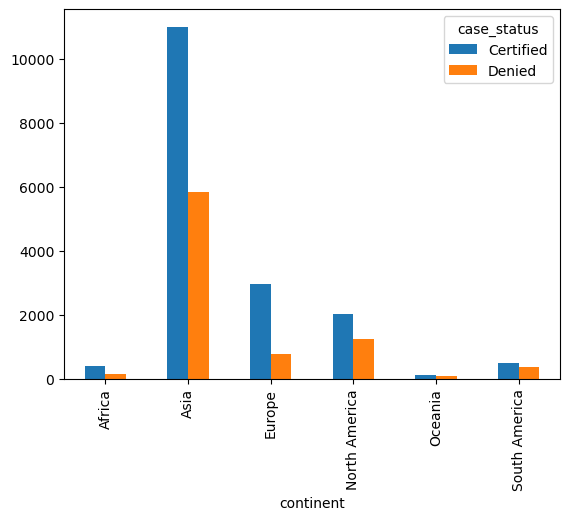

In [22]:
col1=visa_df['case_status']
col2=visa_df['continent']
r1=pd.crosstab(col2,col1)
r1.plot(kind='bar')

- categorical : **Frequncy table bar chart pie**

- numerical : **Histogram**

- categorical vs categorical : **pd.crosstab**

- numerical vs numerical : **scatterplots,cova,corre**

**Scatter plot**

- It is a graph representation between two numerical columns.

- It is also gives the relationship status between two columns.

    - positive or negative or no realtion 

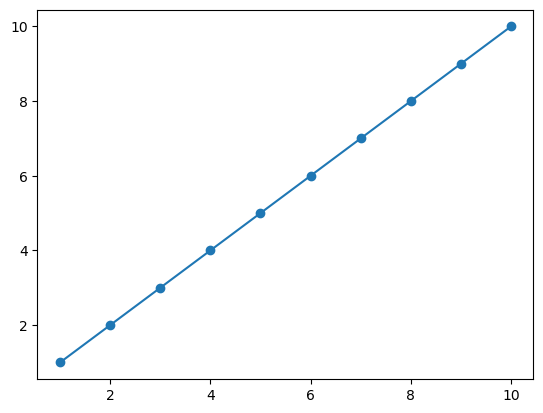

In [31]:
x=range(1,11)
y=range(1,11)
plt.scatter(x,y)
plt.plot(x,y)
plt.show()

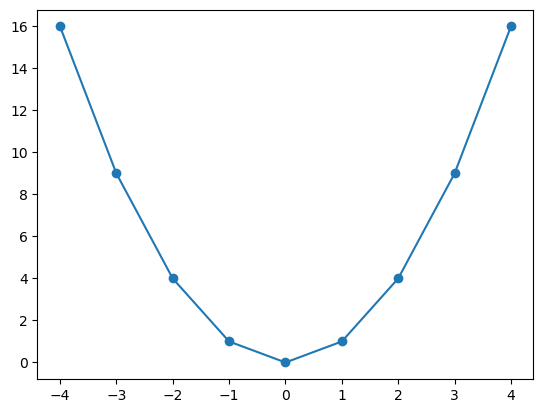

In [33]:
x=range(-4,5)
y=np.square(x)
plt.scatter(x,y)
plt.plot(x,y)

In [6]:
num

NameError: name 'num' is not defined

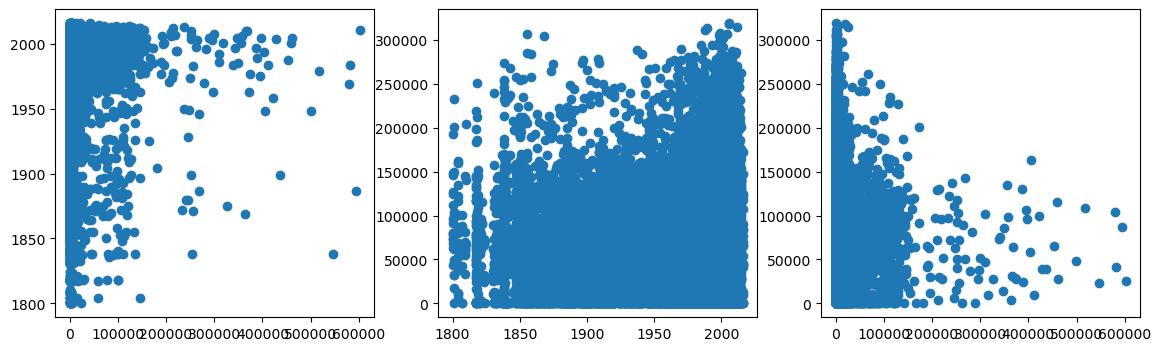

In [7]:
col1=visa_df['no_of_employees']
col2=visa_df['yr_of_estab']
col3=visa_df['prevailing_wage']
plt.figure(figsize=(14,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)

- we have draw the scatter plots for numerical columns

- by seeing above plots we are not able to identify the relationship accuractly

- to get more confidence will go to correlation matrix

In [3]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


In [9]:
winequality_df=pd.read_csv(r"C:\Users\Patel\Documents\NareshIt\EDA\winequality_red.csv")
winequality_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [11]:
winequality_df.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


**Heatmap**

- so far whatever the plots we did the same we can implemnent by using seaborn

- bar, countplots,histogram,distribution,boxplot

<Axes: >

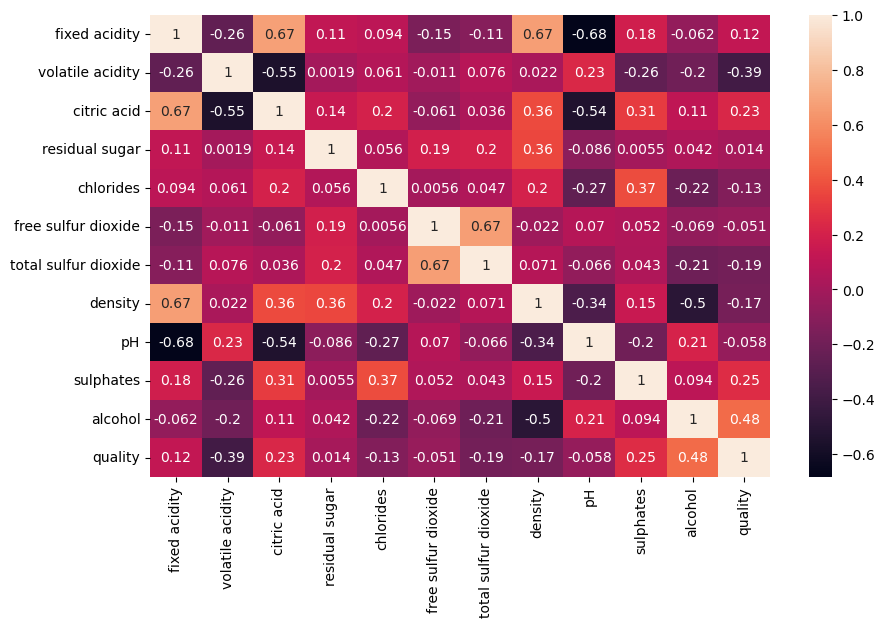

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(winequality_df.corr(),
           annot=True)